**Project title - Plant Leaf Disease Detection using Incremental Learning**

Install Required Libraries

In [47]:
# Install required libraries
# TensorFlow -> Deep learning framework
# TensorFlow Datasets -> Directly load PlantVillage dataset
# OpenCV -> Image processing
# Matplotlib -> Graph visualization
# scikit-learn -> Evaluation metrics

!pip install tensorflow tensorflow-datasets opencv-python matplotlib scikit-learn

Import Libraries

In [49]:
# Import necessary Python libraries

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.metrics import confusion_matrix, classification_report

Load PlantVillage Dataset

In [51]:
# Load PlantVillage dataset directly using TensorFlow Datasets
# No need to manually download or upload dataset

(dataset_train, dataset_test), dataset_info = tfds.load(
    "plant_village",
    split=["train[:80%]", "train[80%:]"],   # 80% training and 20% testing
    as_supervised=True,
    with_info=True
)

# Get total number of disease classes
num_classes = dataset_info.features["label"].num_classes

# Get disease class names
class_names = dataset_info.features["label"].names

print("Total number of classes:", num_classes)

Total number of classes: 38


Image Preprocessing

In [53]:
# Define image size and batch size
# Smaller image size makes training faster without affecting accuracy much

IMG_SIZE = 128
BATCH_SIZE = 32

# Function to preprocess images
def preprocess(image, label):

    # Resize image
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Normalize pixel values between 0 and 1
    image = image / 255.0

    return image, label

Create Efficient Data Pipeline

In [55]:
# AUTOTUNE lets TensorFlow automatically optimize performance

AUTOTUNE = tf.data.AUTOTUNE

# Prepare training dataset
train_dataset = dataset_train.map(preprocess, num_parallel_calls=AUTOTUNE)\
                             .shuffle(1000)\
                             .batch(BATCH_SIZE)\
                             .prefetch(AUTOTUNE)

# Prepare testing dataset
test_dataset = dataset_test.map(preprocess, num_parallel_calls=AUTOTUNE)\
                           .batch(BATCH_SIZE)\
                           .prefetch(AUTOTUNE)

Load Pretrained Model (Transfer Learning)

In [60]:
# Use MobileNetV2 pretrained on ImageNet
# Transfer learning helps achieve higher accuracy and faster training

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers so they are not retrained
base_model.trainable = False

Build Final Model

In [62]:
# Build the final neural network model

model = tf.keras.Sequential([

    # Feature extraction using MobileNetV2
    base_model,

    # Convert feature maps to vector
    tf.keras.layers.GlobalAveragePooling2D(),

    # Fully connected layer
    tf.keras.layers.Dense(256, activation="relu"),

    # Dropout helps prevent overfitting
    tf.keras.layers.Dropout(0.5),

    # Output layer with Softmax activation
    tf.keras.layers.Dense(num_classes, activation="softmax")

])

Compile Model

In [64]:
# Compile the model by defining optimizer, loss function, and evaluation metric

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train the Model

In [65]:
# Train the model using training dataset
# Validate performance using testing dataset

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 764s 557ms/step - accuracy: 0.7167 - loss: 1.0357 - val_accuracy: 0.9197 - val_loss: 0.2470
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 794s 551ms/step - accuracy: 0.8880 - loss: 0.3447 - val_accuracy: 0.9306 - val_loss: 0.2081
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 814s 599ms/step - accuracy: 0.9090 - loss: 0.2812 - val_accuracy: 0.9427 - val_loss: 0.1742
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 797s 551ms/step - accuracy: 0.9149 - loss: 0.2479 - val_accuracy: 0.9433 - val_loss: 0.1683
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 737s 542ms/step - accuracy: 0.9260 - loss: 0.2244 - val_accuracy: 0.9440 - val_loss: 0.1687


Incremental Learning Step

In [66]:
# Incremental learning means updating the model with new incoming data

new_data = train_dataset.take(200)

print("Updating model with new data...")

model.fit(new_data, epochs=2)

Updating model with new data...
Epoch 1/2
200/200 ━━━━━━━━━━━━━━━━━━━━ 89s 438ms/step - accuracy: 0.9261 - loss: 0.2125
Epoch 2/2
200/200 ━━━━━━━━━━━━━━━━━━━━ 142s 437ms/step - accuracy: 0.9366 - loss: 0.1746


Model Evaluation

In [67]:
# Evaluate model performance on test dataset

loss, accuracy = model.evaluate(test_dataset)

print("Final Test Accuracy:", accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 145s 426ms/step - accuracy: 0.9453 - loss: 0.1619
Final Test Accuracy: 0.9471503496170044


Accuracy Graph

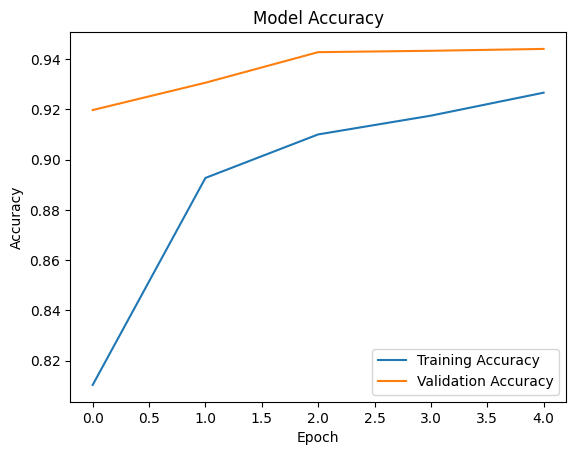

In [68]:
# Plot training accuracy vs validation accuracy

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy","Validation Accuracy"])

plt.show()

Confusion Matrix

In [69]:
# Generate confusion matrix to evaluate classification performance

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

Classification Report

In [70]:
# Generate precision, recall and F1-score for each disease class

print("Classification Report:")

print(classification_report(y_true, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.90       129
           1       0.96      0.99      0.97       154
           2       1.00      0.93      0.96        54
           3       0.99      0.94      0.96       339
           4       0.96      1.00      0.98       292
           5       0.97      0.99      0.98       195
           6       1.00      0.94      0.97       201
           7       0.86      0.81      0.83       108
           8       1.00      1.00      1.00       239
           9       1.00      1.00      1.00       223
          10       0.89      0.91      0.90       197
          11       0.98      0.95      0.97       224
          12       0.96      0.98      0.97       272
          13       1.00      1.00      1.00        74
          14       0.99      0.99      0.99       195
          15       0.99      0.99      0.99      1108
          16       0.98      0.99      0.99       459
    

Leaf Image → Disease Prediction

In [71]:
# Upload a leaf image from your computer

from google.colab import files

uploaded = files.upload()

Saving 2cdea224-6f10-4a3d-a3f1-1debd1a42640___JR_B.Spot 8926.JPG to 2cdea224-6f10-4a3d-a3f1-1debd1a42640___JR_B.Spot 8926.JPG


Prediction Function

In [72]:
# Function to predict plant disease from a leaf image

def predict_disease(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    predicted_class = np.argmax(prediction)

    disease_name = class_names[predicted_class]

    print("Predicted Disease:", disease_name)

    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title(disease_name)
    plt.axis("off")
    plt.show()

Run Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
Predicted Disease: Pepper,_bell___Bacterial_spot


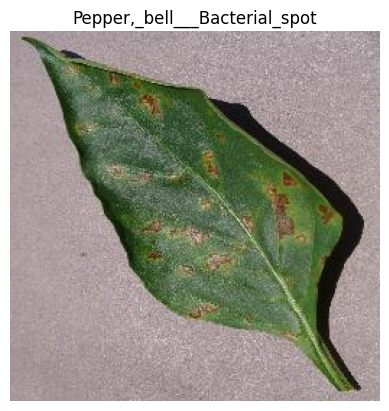

In [73]:
# Example prediction

predict_disease("2cdea224-6f10-4a3d-a3f1-1debd1a42640___JR_B.Spot 8926.JPG")